In [ ]:
# Task 3: Classification & Clustering on the Kaggle "gene expression cancer RNA-Seq" dataset
# Dataset: https://www.kaggle.com/datasets/waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

DATA_DIR = "."   # change to r"D:\SEM3\ML\KrishnaKant Sir\Assignment" if running outside that folder
DATA_FILE = os.path.join(DATA_DIR, "data.csv")
LABELS_FILE = os.path.join(DATA_DIR, "labels.csv")
OUTPUT_DIR = os.path.join(DATA_DIR, "task3_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42

In [2]:
# Load the dataset (falls back to a synthetic demo dataset if the real CSVs aren't present)
if os.path.exists(DATA_FILE) and os.path.exists(LABELS_FILE):
    data_df = pd.read_csv(DATA_FILE, index_col=0)
    labels_df = pd.read_csv(LABELS_FILE, index_col=0)
    print("Loaded real dataset.")
else:
    print("data.csv / labels.csv not found -> generating a synthetic demo dataset instead.")
    rng = np.random.RandomState(RANDOM_STATE)
    n_samples, n_genes, classes = 150, 2000, ["BRCA", "KIRC", "COAD", "LUAD", "PRAD"]
    y_demo = rng.choice(classes, size=n_samples)
    X_demo = rng.rand(n_samples, n_genes)
    # inject a class-dependent signal into the first 20 genes so the demo is learnable
    for i, c in enumerate(classes):
        X_demo[y_demo == c, :20] += i * 0.8
    data_df = pd.DataFrame(X_demo, index=[f"sample_{i}" for i in range(n_samples)],
                            columns=[f"gene_{i:04d}" for i in range(n_genes)])
    labels_df = pd.DataFrame({"Class": y_demo}, index=data_df.index)

X = data_df.values
label_col = "Class" if "Class" in labels_df.columns else labels_df.columns[0]
y_raw = labels_df[label_col].values

print(f"Data shape: {X.shape}")
print(f"Classes: {sorted(set(y_raw))}")

le = LabelEncoder()
y = le.fit_transform(y_raw)

data.csv / labels.csv not found -> generating a synthetic demo dataset instead.
Data shape: (150, 2000)
Classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']


In [3]:
# Preprocess: scale, then reduce dimensionality with PCA
# (genes run into the thousands, so PCA keeps most of the variance while making models fast)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=min(50, X_scaled.shape[0] - 1, X_scaled.shape[1]), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA({pca.n_components_}) explained variance: {pca.explained_variance_ratio_.sum():.3f}")

PCA(50) explained variance: 0.434


In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

results = []  # will collect {"Model": ..., "Accuracy": ...} from each model cell below

def evaluate_model(name, model):
    """Fit, evaluate, plot confusion matrix, and record accuracy for one classifier."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc})

    print(f"--- {name} (accuracy = {acc:.4f}) ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_{name.replace(' ', '_')}.png"))
    plt.show()
    return model

Train shape: (120, 50) | Test shape: (30, 50)


--- Logistic Regression (accuracy = 0.3667) ---
              precision    recall  f1-score   support

        BRCA       0.50      0.40      0.44         5
        COAD       0.17      0.20      0.18         5
        KIRC       0.50      0.50      0.50         6
        LUAD       0.38      0.38      0.38         8
        PRAD       0.33      0.33      0.33         6

    accuracy                           0.37        30
   macro avg       0.37      0.36      0.37        30
weighted avg       0.38      0.37      0.37        30



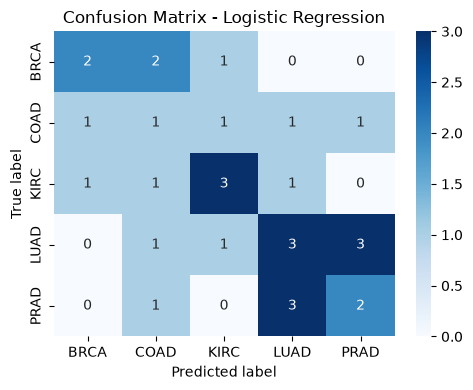

In [5]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg = evaluate_model("Logistic Regression", log_reg)

--- SVM (accuracy = 0.4333) ---
              precision    recall  f1-score   support

        BRCA       1.00      0.20      0.33         5
        COAD       0.00      0.00      0.00         5
        KIRC       0.50      0.67      0.57         6
        LUAD       0.44      0.88      0.58         8
        PRAD       0.50      0.17      0.25         6

    accuracy                           0.43        30
   macro avg       0.49      0.38      0.35        30
weighted avg       0.48      0.43      0.38        30



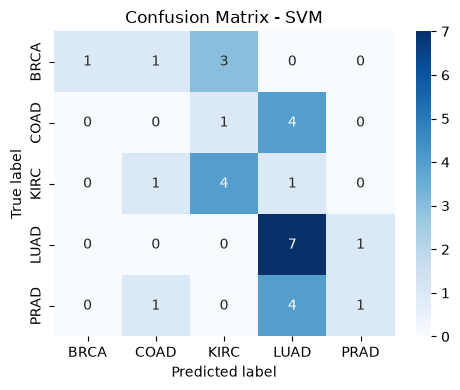

In [6]:
# Model 2: Support Vector Machine
svm_clf = SVC(kernel="rbf", random_state=RANDOM_STATE)
svm_clf = evaluate_model("SVM", svm_clf)

--- Naive Bayes (accuracy = 0.7333) ---
              precision    recall  f1-score   support

        BRCA       1.00      0.60      0.75         5
        COAD       1.00      0.40      0.57         5
        KIRC       0.67      1.00      0.80         6
        LUAD       0.64      0.88      0.74         8
        PRAD       0.80      0.67      0.73         6

    accuracy                           0.73        30
   macro avg       0.82      0.71      0.72        30
weighted avg       0.80      0.73      0.72        30



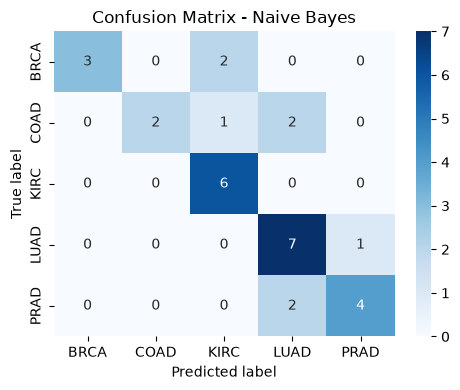

In [7]:
# Model 3: Naive Bayes Classifier
nb_clf = GaussianNB()
nb_clf = evaluate_model("Naive Bayes", nb_clf)

--- KNN (accuracy = 0.3667) ---
              precision    recall  f1-score   support

        BRCA       0.57      0.80      0.67         5
        COAD       0.12      0.20      0.15         5
        KIRC       0.33      0.17      0.22         6
        LUAD       0.44      0.50      0.47         8
        PRAD       0.33      0.17      0.22         6

    accuracy                           0.37        30
   macro avg       0.36      0.37      0.35        30
weighted avg       0.37      0.37      0.35        30



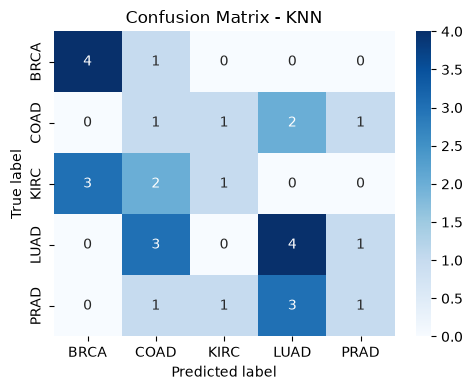

In [8]:
# Model 4: K-Nearest Neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf = evaluate_model("KNN", knn_clf)

--- Random Forest (accuracy = 0.7333) ---
              precision    recall  f1-score   support

        BRCA       0.67      0.40      0.50         5
        COAD       1.00      0.40      0.57         5
        KIRC       0.56      0.83      0.67         6
        LUAD       0.73      1.00      0.84         8
        PRAD       1.00      0.83      0.91         6

    accuracy                           0.73        30
   macro avg       0.79      0.69      0.70        30
weighted avg       0.78      0.73      0.72        30



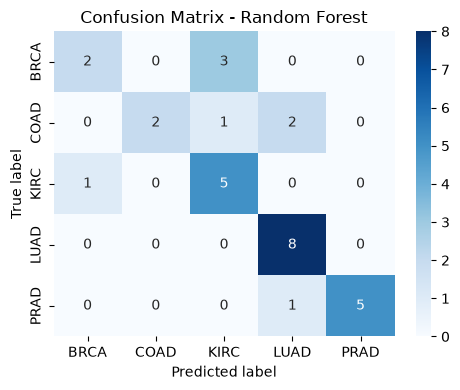

In [9]:
# Model 5: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_clf = evaluate_model("Random Forest", rf_clf)

                 Model  Accuracy
2          Naive Bayes  0.733333
4        Random Forest  0.733333
1                  SVM  0.433333
0  Logistic Regression  0.366667
3                  KNN  0.366667


C:\Users\Yashika\AppData\Local\Temp\ipykernel_2992\1946882257.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette="viridis")


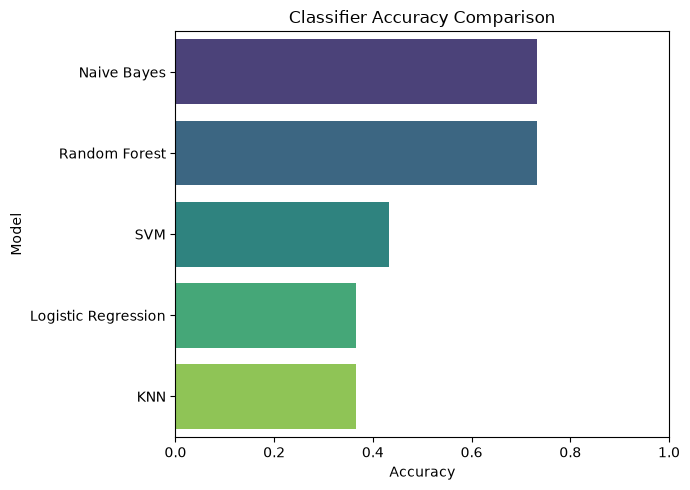

In [10]:
# Compare all classifiers
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "classification_results.csv"), index=False)
print(results_df)

plt.figure(figsize=(7, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="viridis")
plt.title("Classifier Accuracy Comparison")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "classifier_comparison.png"))
plt.show()

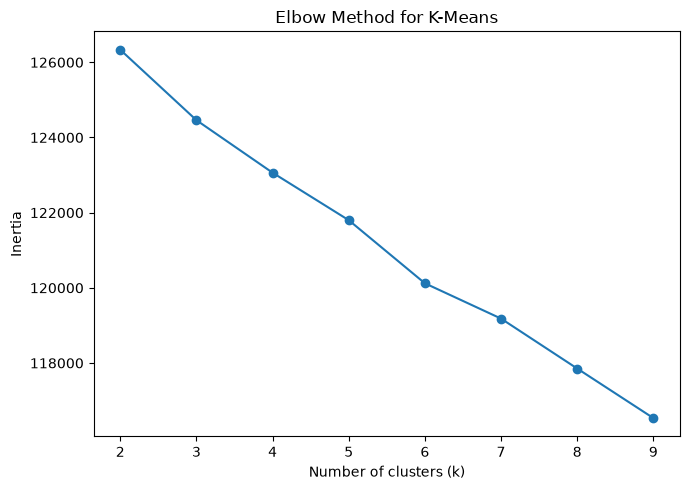

In [11]:
# K-Means Clustering: elbow method to sanity-check cluster count
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kmeans_elbow.png"))
plt.show()

In [12]:
# K-Means Clustering: fit using the true number of classes, then score against true labels
n_clusters = len(np.unique(y))
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)
sil = silhouette_score(X_pca, cluster_labels)
print(f"Adjusted Rand Index (vs true labels): {ari:.4f}")
print(f"Normalized Mutual Info (vs true labels): {nmi:.4f}")
print(f"Silhouette Score: {sil:.4f}")

with open(os.path.join(OUTPUT_DIR, "clustering_metrics.txt"), "w") as f:
    f.write(f"Adjusted Rand Index: {ari:.4f}\n")
    f.write(f"Normalized Mutual Info: {nmi:.4f}\n")
    f.write(f"Silhouette Score: {sil:.4f}\n")

Adjusted Rand Index (vs true labels): 0.1522
Normalized Mutual Info (vs true labels): 0.2345
Silhouette Score: 0.0110


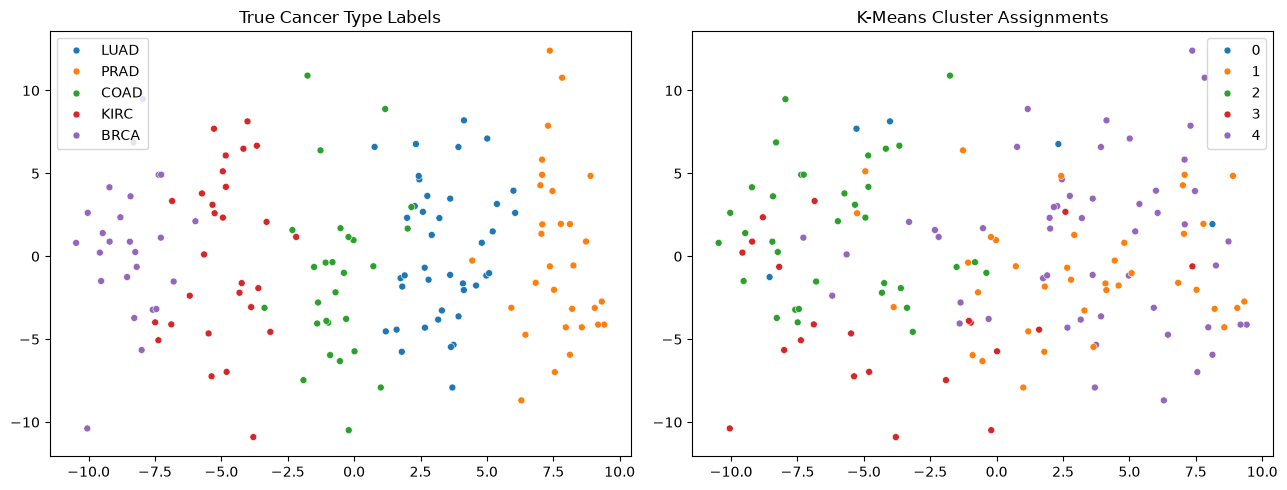

All outputs saved to: .\task3_outputs


In [13]:
# Visualize K-Means clusters vs true labels (first 2 PCA components)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=le.inverse_transform(y),
                 palette="tab10", ax=axes[0], s=25)
axes[0].set_title("True Cancer Type Labels")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels,
                 palette="tab10", ax=axes[1], s=25)
axes[1].set_title("K-Means Cluster Assignments")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "clusters_vs_true_labels.png"))
plt.show()

print(f"All outputs saved to: {OUTPUT_DIR}")